# 0교시 · VLM 구조 실습 — 이미지가 '토큰'이 되는 과정

> **VLM 경량화 과정 · 0교시(사전 학습) · 실습 2**
> 실습 환경: **Google Colab (CPU만 사용 — GPU 불필요)**
> 대상: **비전공자 / AI 입문자**

---

## 이 실습의 목표
VLM(Vision-Language Model)은 이미지를 직접 "보는" 것이 아니라, 이미지를 잘게 쪼개서 **글자(토큰)처럼 변환**한 뒤 언어모델(LLM)에게 넘겨줍니다.
이 노트북은 작은 가짜 이미지를 직접 만들어서, 다음 3단계가 실제로 어떻게 동작하는지 **직접 눈으로 확인**합니다.

1. **비전 인코더(ViT)** — 이미지를 16×16 픽셀 패치로 자르고, 각 패치를 숫자 벡터로 바꾼다
2. **Connector/Merger** — 인접한 2×2 패치 4개를 묶어서 "이미지 토큰" 1개로 압축한다 (토큰 수 1/4로 감소)
3. **LLM** — 이미지 토큰과 텍스트 토큰을 하나의 시퀀스로 합쳐서 받는다

> 이 노트북도 실제 신경망 모델을 불러오지 않습니다. **패치 자르기·픽셀 평균내기·토큰 합치기** 같은 핵심 연산만 NumPy로 직접 구현하면서 구조를 체험합니다.


## 1단계 준비 — 작은 가짜 이미지 만들기

실제 사진 대신, 이해하기 쉬운 **64×64 픽셀의 간단한 패턴 이미지**를 직접 만들어 보겠습니다.
(가로 64픽셀, 세로 64픽셀, 색상 3채널(RGB) — 작은 컬러 그림이라고 생각하면 됩니다.)


## 0단계 — (Colab 전용) 한글 폰트 설정

아래 셀은 그래프에 한글이 깨지지 않고 잘 보이도록 폰트를 설치합니다. **Google Colab에서 한 번만 실행**하면 됩니다 (로컬 Jupyter에서는 생략 가능).

In [ ]:
# Colab 환경에서 한글이 깨지지 않도록 폰트를 설치합니다 (최초 1회만 실행, 약 10~20초 소요)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, subprocess, sys

def setup_korean_font():
    try:
        # 나눔고딕 폰트 설치 (Colab/Ubuntu 환경)
        if not os.path.exists('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'):
            subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], check=False,
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
        plt.rcParams['font.family'] = 'NanumGothic'
        plt.rcParams['axes.unicode_minus'] = False
        print('한글 폰트 설정 완료 (NanumGothic)')
    except Exception as e:
        print('한글 폰트 자동 설정에 실패했습니다. 그래프의 한글이 깨져 보일 수 있습니다.')
        print('(실행에는 문제 없으며, 그림 설명은 텍스트로도 제공됩니다.)')

setup_korean_font()

한글 폰트 설정 완료 (NanumGothic)


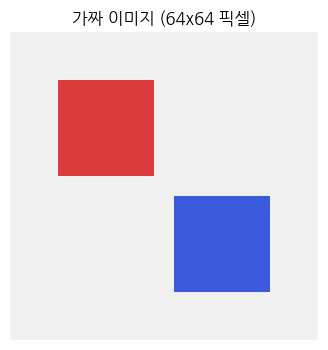

이미지 배열 크기: (64, 64, 3)  (세로, 가로, 채널)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 64x64 크기의 컬러 이미지를 직접 생성 (왼쪽은 빨간 사각형, 오른쪽은 파란 사각형이 있는 단순한 그림)
H, W, C = 64, 64, 3
image = np.zeros((H, W, C), dtype=np.uint8)
image[:, :, :] = 240  # 전체 배경은 밝은 회색

image[10:30, 10:30, 0] = 220  # 왼쪽 위에 빨간 사각형 (R채널)
image[10:30, 10:30, 1] = 60
image[10:30, 10:30, 2] = 60

image[34:54, 34:54, 0] = 60   # 오른쪽 아래에 파란 사각형 (B채널)
image[34:54, 34:54, 1] = 90
image[34:54, 34:54, 2] = 220

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title(f"가짜 이미지 ({W}x{H} 픽셀)")
plt.axis('off')
plt.show()

print(f"이미지 배열 크기: {image.shape}  (세로, 가로, 채널)")


### 결과 해석
방금 만든 이미지는 사실 `(64, 64, 3)` 크기의 숫자 배열일 뿐입니다 — 빨간 사각형, 파란 사각형, 회색 배경이 각각 RGB 숫자값으로 표현되어 있습니다.
VLM은 바로 이 "숫자 배열"을 입력으로 받습니다.


## 2단계 — 비전 인코더(ViT): 이미지를 패치로 자르기

VLM의 첫 단계는 이미지를 **작은 정사각형 조각(패치)**으로 자르는 것입니다. 실제 Qwen3-VL은 16×16 픽셀 패치를 쓰지만, 여기서는 이해하기 쉽도록 64×64 이미지를 **16×16 픽셀 패치**로 잘라보겠습니다.

$$\text{패치 개수} = \frac{\text{가로}}{\text{patch\_size}} \times \frac{\text{세로}}{\text{patch\_size}} = \frac{64}{16} \times \frac{64}{16} = 4 \times 4 = 16\text{개}$$


In [ ]:
patch_size = 16

# 이미지를 patch_size x patch_size 크기의 작은 조각들로 자르기
def split_into_patches(img, patch_size):
    h, w, c = img.shape
    n_rows = h // patch_size
    n_cols = w // patch_size
    patches = []
    for r in range(n_rows):
        for col in range(n_cols):
            patch = img[r*patch_size:(r+1)*patch_size, col*patch_size:(col+1)*patch_size, :]
            patches.append(patch)
    return patches, n_rows, n_cols

patches, n_rows, n_cols = split_into_patches(image, patch_size)
print(f"이미지를 {patch_size}x{patch_size} 패치로 자른 결과:")
print(f"  패치 격자: {n_rows}행 x {n_cols}열 = {len(patches)}개의 패치")
print(f"  패치 1개의 크기: {patches[0].shape}")


이미지를 16x16 패치로 자른 결과:
  패치 격자: 4행 x 4열 = 16개의 패치
  패치 1개의 크기: (16, 16, 3)


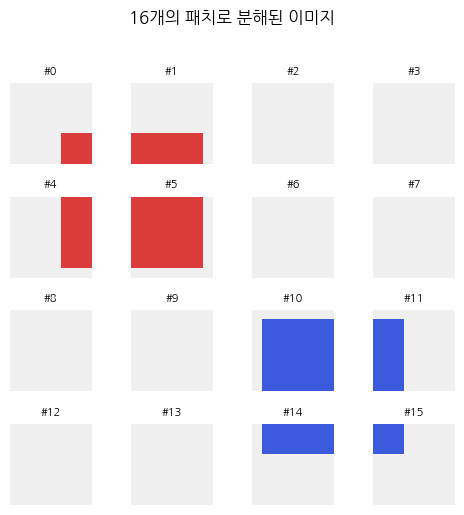

In [ ]:
# 잘린 패치들을 격자 형태로 시각화 (각 패치 사이에 흰 선을 넣어 구분)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 5))
for idx, patch in enumerate(patches):
    r, c = idx // n_cols, idx % n_cols
    axes[r, c].imshow(patch)
    axes[r, c].axis('off')
    axes[r, c].set_title(f"#{idx}", fontsize=8)
plt.suptitle(f"{len(patches)}개의 패치로 분해된 이미지", y=1.02)
plt.tight_layout()
plt.show()


### 결과 해석
원본 이미지 1장이 16개의 작은 조각(패치)으로 나뉘었습니다. 각 패치는 여전히 `(16, 16, 3)` 크기의 숫자 배열입니다.
빨간 사각형이 있던 자리의 패치들은 빨갛게, 파란 사각형이 있던 자리는 파랗게, 나머지는 회색으로 보이는 것을 확인할 수 있습니다.

> 실제 Qwen3-VL-4B에서 448×448 이미지를 16×16 패치로 자르면 `448/16 × 448/16 = 28×28 = 784개`의 패치가 나옵니다. 우리는 작은 예시(16개)로 같은 원리를 체험하는 것입니다.


## 3단계 — 패치를 벡터로 인코딩하기 (ViT 임베딩, 단순화 버전)

실제 ViT(Vision Transformer)는 복잡한 신경망으로 각 패치를 고차원 벡터(예: 1024차원)로 변환합니다.
여기서는 신경망 대신, **"패치의 평균 색상값을 벡터로 쓰는"** 매우 단순화된 방식으로 그 원리만 체험합니다.

(실제로는 학습된 가중치를 이용한 복잡한 변환이지만, "이미지 조각 → 숫자 벡터로 바꾼다"는 핵심 아이디어는 동일합니다.)


In [ ]:
def simple_patch_embedding(patch):
    '''패치를 단순화된 벡터로 변환: R,G,B 평균값 3개 + 패치 내 색상 변화(표준편차) 3개 = 6차원 벡터'''
    mean_rgb = patch.reshape(-1, 3).mean(axis=0)   # R,G,B 평균
    std_rgb = patch.reshape(-1, 3).std(axis=0)     # R,G,B 표준편차(색이 얼마나 다양한지)
    return np.concatenate([mean_rgb, std_rgb])      # 6차원 벡터로 합치기

patch_vectors = np.array([simple_patch_embedding(p) for p in patches])
print(f"패치 벡터들의 크기: {patch_vectors.shape}  (패치 개수, 벡터 차원)")
print()
print("패치별 벡터값 (R평균, G평균, B평균, R편차, G편차, B편차):")
for idx, vec in enumerate(patch_vectors):
    print(f"  패치 #{idx:2d}: {np.round(vec, 1)}")


패치 벡터들의 크기: (16, 6)  (패치 개수, 벡터 차원)

패치별 벡터값 (R평균, G평균, B평균, R편차, G편차, B편차):
  패치 # 0: [237.2 214.7 214.7   7.   62.6  62.6]
  패치 # 1: [233.4 180.9 180.9   9.4  84.5  84.5]
  패치 # 2: [240. 240. 240.   0.   0.   0.]
  패치 # 3: [240. 240. 240.   0.   0.   0.]
  패치 # 4: [233.4 180.9 180.9   9.4  84.5  84.5]
  패치 # 5: [224.7 102.2 102.2   8.5  76.2  76.2]
  패치 # 6: [240. 240. 240.   0.   0.   0.]
  패치 # 7: [240. 240. 240.   0.   0.   0.]
  패치 # 8: [240. 240. 240.   0.   0.   0.]
  패치 # 9: [240. 240. 240.   0.   0.   0.]
  패치 #10: [102.2 125.2 224.7  76.2  63.5   8.5]
  패치 #11: [180.9 190.8 233.4  84.5  70.4   9.4]
  패치 #12: [240. 240. 240.   0.   0.   0.]
  패치 #13: [240. 240. 240.   0.   0.   0.]
  패치 #14: [180.9 190.8 233.4  84.5  70.4   9.4]
  패치 #15: [214.7 218.9 237.2  62.6  52.1   7. ]


### 결과 해석
- 빨간 사각형이 있던 패치(예: #0, #1, #4, #5)는 R(빨강)값이 높게 나옵니다.
- 파란 사각형이 있던 패치(예: #10, #11, #14, #15)는 B(파랑)값이 높게 나옵니다.
- 배경만 있는 패치는 R,G,B가 거의 비슷한 회색 값으로 나옵니다.

실제 ViT는 6차원이 아니라 1024차원(Qwen3-VL 기준)으로 훨씬 풍부하게 표현하지만, **"이미지 조각의 시각적 특징을 숫자 벡터로 압축한다"**는 원리는 동일합니다.


## 4단계 — Connector/Merger: 2×2 패치를 묶어서 '이미지 토큰' 만들기

Qwen3-VL은 인접한 **2×2 패치(4개)를 하나로 묶어서** 토큰 수를 1/4로 줄입니다. 우리의 4×4 패치 격자에서는 2×2 묶음이 **2×2=4개**의 "이미지 토큰"이 됩니다.

$$\text{이미지 토큰 개수} = \frac{\text{패치 행}}{2} \times \frac{\text{패치 열}}{2} = \frac{4}{2} \times \frac{4}{2} = 2 \times 2 = 4\text{개}$$

각 토큰의 벡터 차원도 늘어납니다 — 4개 패치(각 6차원)를 이어붙이면 `6×4 = 24`차원이 됩니다 (실제 모델은 `1024×4=4096`차원을 거쳐 `2560`차원으로 projection).


In [ ]:
def merge_2x2(patch_vectors, n_rows, n_cols, merge_size=2):
    '''인접한 2x2 패치 벡터 4개를 이어붙여 하나의 이미지토큰 벡터로 합치기'''
    merged_tokens = []
    merge_rows = n_rows // merge_size
    merge_cols = n_cols // merge_size
    for mr in range(merge_rows):        # mr = 0, 1
        for mc in range(merge_cols):    # nc = 0, 1     -> (2*2)
            # 2x2 블록에 해당하는 4개의 패치 인덱스를 찾기
            idxs = []
            for dr in range(merge_size):
                for dc in range(merge_size):
                    r = mr * merge_size + dr
                    c = mc * merge_size + dc
                    idxs.append(r * n_cols + c)
            # 4개 패치 벡터를 순서대로 이어붙임(concatenate)
            merged_vec = np.concatenate([patch_vectors[i] for i in idxs])
            merged_tokens.append(merged_vec)
    return np.array(merged_tokens)

image_tokens = merge_2x2(patch_vectors, n_rows, n_cols, merge_size=2)
print(f"병합 전: 패치 {len(patches)}개 (각 {patch_vectors.shape[1]}차원)")
print(f"병합 후: 이미지 토큰 {image_tokens.shape[0]}개 (각 {image_tokens.shape[1]}차원)")
print(f"\n→ 토큰 개수가 {len(patches)}개에서 {image_tokens.shape[0]}개로, 정확히 1/4로 줄었습니다.")


병합 전: 패치 16개 (각 6차원)
병합 후: 이미지 토큰 4개 (각 24차원)

→ 토큰 개수가 16개에서 4개로, 정확히 1/4로 줄었습니다.


### 결과 해석
패치 16개가 4개의 "이미지 토큰"으로 압축되었습니다. 각 토큰의 차원은 늘어났지만(6차원 → 24차원), **개수는 1/4로 줄었습니다.**

실제 Qwen3-VL-4B에서는:
- 패치 1024차원 × 4개 = 4096차원으로 이어붙인 뒤
- 작은 신경망(MLP)이 이를 LLM과 같은 **2560차원**으로 다시 변환(projection)합니다.

우리 실습에서는 신경망 변환(projection) 단계를 생략하고 단순 이어붙이기까지만 구현했지만, **"여러 패치를 하나의 토큰으로 압축한다"**는 핵심 구조는 동일합니다.

### 미니 퀴즈
만약 원본 이미지가 128×128이고 패치 크기가 16이라면, 그리고 2×2 병합을 한다면, 최종 이미지 토큰은 몇 개가 될까요?


In [ ]:
# 미니 퀴즈: 128x128 이미지, patch_size=16, merge_size=2 일 때 이미지 토큰 개수는?
img_w, img_h = 128, 128
patch_size_q = 16
merge_size_q = 2

# 힌트: 먼저 패치 개수를 구하고, 그 다음 2x2씩 묶은 개수를 구해보세요.
n_patches_per_side = img_w // patch_size_q       # 한 변의 패치 개수
n_tokens_per_side = n_patches_per_side // merge_size_q  # 병합 후 한 변의 토큰 개수
total_tokens = n_tokens_per_side ** 2

print(f"패치: 한 변에 {n_patches_per_side}개 → 총 {n_patches_per_side**2}개")
print(f"이미지 토큰: 한 변에 {n_tokens_per_side}개 → 총 {total_tokens}개")


패치: 한 변에 8개 → 총 64개
이미지 토큰: 한 변에 4개 → 총 16개


## 5단계 — 해상도가 커지면 토큰이 얼마나 늘어나는가

지난 시간 본문 노트북에서 다룬 핵심 내용을 직접 함수로 만들어 확인해 봅니다 — **해상도가 커질수록 이미지 토큰 수가 "제곱"으로 늘어난다**는 사실입니다.


In [ ]:
def estimate_visual_tokens(width, height, patch_size=16, merge_size=2):
    '''해상도로부터 이미지 토큰 수를 추정'''
    eff = patch_size * merge_size
    cols = max(1, round(width / eff))
    rows = max(1, round(height / eff))
    tokens = cols * rows
    return tokens, (cols, rows)

print(f"{'해상도':<14}{'이미지 토큰 수':>14}{'토큰 격자':>12}")
print("-" * 40)
resolutions = [(64, 64), (128, 128), (256, 256), (448, 448), (896, 896)]
prev_tokens = None
for (w, h) in resolutions:
    tokens, grid = estimate_visual_tokens(w, h)
    ratio_str = ""
    if prev_tokens:
        ratio_str = f"  (이전 대비 {tokens/prev_tokens:.0f}배)"
    print(f"{w}x{h:<10}{tokens:>14}  {grid[0]}x{grid[1]}{ratio_str}")
    prev_tokens = tokens


해상도                 이미지 토큰 수       토큰 격자
----------------------------------------
64x64                     4  2x2
128x128                   16  4x4  (이전 대비 4배)
256x256                   64  8x8  (이전 대비 4배)
448x448                  196  14x14  (이전 대비 3배)
896x896                  784  28x28  (이전 대비 4배)


### 결과 해석
해상도(가로·세로)를 2배씩 늘릴 때마다 이미지 토큰 수는 약 **4배(=2×2)**씩 증가합니다 — 면적이 가로×세로로 곱해지기 때문입니다.

이것이 지난 노트북에서 다룬 "왜 고해상도 이미지가 활성값(activation) 메모리를 폭증시키는가"의 직접적인 원인입니다. **이미지 토큰도 결국 텍스트 토큰과 똑같이 시퀀스 길이를 차지**하기 때문에, 토큰이 늘어나면 학습/추론에 필요한 메모리도 함께 늘어납니다.


## 6단계 — LLM: 이미지 토큰과 텍스트 토큰을 하나의 시퀀스로 합치기

마지막 단계입니다. LLM은 "이미지 토큰"과 "텍스트 토큰"을 구분하지 않고, **하나의 긴 시퀀스(순서가 있는 목록)**로 받습니다.
예를 들어 "이 그림에서 빨간 사각형은 어디에 있어?"라는 질문이 있다면, 시퀀스는 다음과 같은 순서로 구성됩니다.

```
[이미지 토큰 1] [이미지 토큰 2] [이미지 토큰 3] [이미지 토큰 4] [이 그림에서] [빨간] [사각형은] [어디에] [있어]
   ↑──────────── 이미지(4개 토큰) ────────────↑   ↑──────────── 텍스트(5개 토큰) ────────────↑
```

아래 코드로 우리가 만든 4개의 이미지 토큰과 가상의 텍스트 토큰을 실제로 하나의 시퀀스로 합쳐보겠습니다.


In [ ]:
# 가상의 텍스트 토큰(질문)을 흉내내어 만들기: "이 그림에서 빨간 사각형은 어디에 있어?"
# 실제로는 토크나이저가 변환하지만, 여기서는 이해를 위해 단어 단위로 흉내냅니다.
text_tokens_str = ["이", "그림에서", "빨간", "사각형은", "어디에", "있어"]

# 이미지 토큰 개수 확인 (4단계에서 만든 image_tokens)
n_image_tokens = image_tokens.shape[0]

print(f"이미지 토큰 개수: {n_image_tokens}개")
print(f"텍스트 토큰 개수: {len(text_tokens_str)}개")
print(f"전체 시퀀스 길이: {n_image_tokens + len(text_tokens_str)}개\n")

# 전체 시퀀스를 순서대로 출력 (이미지 토큰 먼저, 그 다음 텍스트 토큰)
sequence = [f"[이미지토큰{i}]" for i in range(n_image_tokens)] + text_tokens_str
print("최종 시퀀스 (LLM이 실제로 받는 입력 순서):")
print(" ".join(sequence))


이미지 토큰 개수: 4개
텍스트 토큰 개수: 6개
전체 시퀀스 길이: 10개

최종 시퀀스 (LLM이 실제로 받는 입력 순서):
[이미지토큰0] [이미지토큰1] [이미지토큰2] [이미지토큰3] 이 그림에서 빨간 사각형은 어디에 있어


### 결과 해석
LLM 입장에서는 "이미지 토큰 4개"와 "텍스트 토큰 6개"가 **차이 없이 하나로 이어진 10개짜리 시퀀스**로 보입니다. LLM은 이 시퀀스를 처음부터 끝까지 읽으면서 답을 생성합니다.

이게 바로 "VLM 입장에서 이미지는 특수한 토큰 묶음일 뿐"이라는 말의 실제 의미입니다 — **이미지도 결국 시퀀스 안의 토큰**이라는 점에서 텍스트와 동등하게 처리됩니다.

### 미니 실습 — 이미지 해상도를 키우면 시퀀스가 얼마나 길어질까?


In [ ]:
# 미니 실습: 해상도별로 전체 시퀀스 길이(이미지토큰+텍스트토큰)를 비교
n_text_tokens = 6  # 질문 텍스트는 고정 (6개 토큰이라고 가정)

print(f"{'해상도':<14}{'이미지 토큰':>12}{'텍스트 토큰':>12}{'전체 시퀀스':>14}")
print("-" * 52)
for (w, h) in [(64, 64), (256, 256), (448, 448), (896, 896)]:
    img_tok, _ = estimate_visual_tokens(w, h)
    total = img_tok + n_text_tokens
    print(f"{w}x{h:<10}{img_tok:>12}{n_text_tokens:>12}{total:>14}")

print("\n→ 텍스트(질문)는 똑같이 6개여도, 이미지 해상도가 커지면 전체 시퀀스가 폭증합니다.")
print("   이것이 VLM 학습/추론에서 '이미지가 곧 메모리 부담'이 되는 이유입니다.")


해상도                 이미지 토큰      텍스트 토큰        전체 시퀀스
----------------------------------------------------
64x64                   4           6            10
256x256                 64           6            70
448x448                196           6           202
896x896                784           6           790

→ 텍스트(질문)는 똑같이 6개여도, 이미지 해상도가 커지면 전체 시퀀스가 폭증합니다.
   이것이 VLM 학습/추론에서 '이미지가 곧 메모리 부담'이 되는 이유입니다.


## 7단계(참고) — DeepStack: 왜 Qwen3-VL이 작은 글자·차트에 강한가

Qwen3-VL은 한 가지 특별한 구조를 더 가지고 있습니다 — **DeepStack**입니다.

- 보통의 VLM은 비전 인코더(ViT)의 **마지막 층 출력 1개만** LLM에 전달합니다.
- DeepStack은 ViT의 **여러 층(예: 초반·중반·후반)의 특징을 동시에** LLM의 여러 층에 나눠서 주입합니다.

**비유**: 그림을 한 번 훑어보고 설명하는 것과, 그림을 여러 번 다른 거리에서(가까이서 세부사항을, 멀리서 전체 구도를) 살펴본 다음 설명하는 것의 차이와 같습니다. 차트나 표처럼 작은 글자·선이 중요한 이미지는, "초반 층의 세밀한 정보"가 살아있어야 정확히 읽을 수 있습니다.

아래 코드로 "여러 층의 정보를 합치는 것"과 "마지막 층만 쓰는 것"의 차이를 간단히 흉내내 봅니다.


In [ ]:
# DeepStack 개념을 아주 단순화해서 흉내내기
# 가정: ViT를 통과하면서 패치 벡터가 "충(layer)"마다 조금씩 달라진다고 가정
np.random.seed(7)

def fake_vit_layers(base_vector, n_layers=3, noise_scale=0.5):
    '''하나의 패치 벡터가 여러 층을 통과하며 조금씩 변한다고 가정하고 흉내냄'''
    layers = [base_vector]
    current = base_vector.copy()
    for _ in range(n_layers - 1):
        current = current + np.random.normal(0, noise_scale, size=current.shape)
        layers.append(current)
    return layers  # [1층 출력, 2층 출력, 3층 출력(마지막)]

sample_patch_vec = patch_vectors[0]  # 패치 #0(빨간 사각형 부분)의 벡터
layers = fake_vit_layers(sample_patch_vec, n_layers=3)

# 방식 A: 보통의 VLM처럼 마지막 층만 사용
last_layer_only = layers[-1]

# 방식 B: DeepStack처럼 여러 층(1층+3층)을 합쳐서 사용
deepstack_combined = (layers[0] + layers[-1]) / 2  # 간단히 평균으로 흉내

print("패치 #0의 원본 벡터:        ", np.round(sample_patch_vec, 2))
print("1층(초반, 세밀한 정보) 출력:  ", np.round(layers[0], 2))
print("3층(후반, 추상화된 정보) 출력:", np.round(layers[-1], 2))
print()
print("[A] 마지막 층만 사용:        ", np.round(last_layer_only, 2))
print("[B] DeepStack(1층+3층 결합): ", np.round(deepstack_combined, 2))
print()
print("→ [B]는 초반 층의 '원본에 가까운 세밀한 정보'를 일부 유지합니다.")
print("   이것이 작은 글자나 촘촘한 차트를 읽을 때 더 유리한 이유입니다.")


패치 #0의 원본 벡터:         [237.19 214.69 214.69   6.95  62.57  62.57]
1층(초반, 세밀한 정보) 출력:   [237.19 214.69 214.69   6.95  62.57  62.57]
3층(후반, 추상화된 정보) 출력: [238.03 213.58 215.21   7.46  61.87  62.49]

[A] 마지막 층만 사용:         [238.03 213.58 215.21   7.46  61.87  62.49]
[B] DeepStack(1층+3층 결합):  [237.61 214.13 214.95   7.2   62.22  62.53]

→ [B]는 초반 층의 '원본에 가까운 세밀한 정보'를 일부 유지합니다.
   이것이 작은 글자나 촘촘한 차트를 읽을 때 더 유리한 이유입니다.


### 결과 해석
이 코드는 실제 DeepStack 알고리즘을 정확히 구현한 것은 아니지만, **"마지막 층 정보만 쓰는 것"과 "여러 층의 정보를 함께 쓰는 것"의 차이**를 직관적으로 보여줍니다.
초반 층은 원본 이미지에 가까운 세밀한 정보(작은 글자, 가는 선)를 담고 있고, 후반 층은 더 추상적이고 의미 중심적인 정보를 담는 경향이 있습니다. DeepStack은 이 둘을 함께 활용해서 ChartQA처럼 세밀한 시각 정보가 중요한 작업에 강점을 가집니다.


## 8. 종합 정리 — VLM 구조 실습에서 확인한 것

| 단계 | 우리가 구현한 것 | 실제 Qwen3-VL에서는 |
|---|---|---|
| 1. 이미지 → 패치 | 64×64 이미지를 16×16 패치 16개로 자름 | 448×448 이미지를 784개 패치로 자름 |
| 2. 패치 → 벡터(ViT) | 평균·표준편차로 6차원 벡터화 | 신경망으로 1024차원 벡터화 |
| 3. 2×2 병합(Merger) | 4개 패치를 이어붙여 24차원 토큰 4개 생성 | 4096차원으로 이어붙인 뒤 2560차원으로 projection |
| 4. 토큰+텍스트 결합 | 이미지토큰 4개+텍스트토큰 6개=시퀀스 10개 | 이미지 토큰 196개+텍스트 토큰 = 전체 시퀀스 |
| 5. 해상도와 토큰 수 | 해상도 2배→토큰 4배 직접 확인 | 동일한 제곱 관계 |
| 6. DeepStack(참고) | 여러 층 결합을 평균으로 흉내 | 여러 ViT 층을 LLM 여러 층에 실제로 주입 |

> **체크포인트**: 다음 질문에 스스로 답해볼 수 있다면 VLM 구조에 대한 기초 준비가 끝난 것입니다.
> 1. 이미지가 패치로 나뉜 뒤, 왜 다시 2×2로 병합하는가?
> 2. 이미지 토큰과 텍스트 토큰은 LLM 입장에서 어떻게 다른가? (힌트: 다르지 않다)
> 3. 해상도를 2배로 늘리면 이미지 토큰 수는 몇 배가 되는가?
> 4. DeepStack이 ChartQA 같은 작업에 유리한 이유는?

---

이 두 노트북(① 비트·양자화·학습메모리, ② VLM 구조)을 마치면, **`Day1_1_경량화개관_양자화기초.ipynb`**의 본문 내용(NF4, 이중 양자화, QLoRA, 학습 메모리 4대 구성, 활성값 스케일링)을 훨씬 쉽게 따라갈 수 있습니다.
